<a href="https://colab.research.google.com/github/oyaon/ML-Dengue-Prediction/blob/main/DhakaDenguePredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [193]:
!pip install tensorflow
!pip install scikit-learn

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.base import BaseEstimator
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ... (Your original data loading and preprocessing code) ...

# ... (Your code to split data into X_train, y_train, X_test, y_test) ...

# 1. Imputation:
imputer = SimpleImputer(strategy='mean')  # Or 'median', 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)  # Apply to test data as well

# 2. Perform feature selection on 2D data (using imputed data):
selector = SelectKBest(score_func=f_regression, k=10)  # Adjust k if needed
X_train_selected_features = selector.fit_transform(X_train_imputed, y_train)
X_test_selected_features = selector.transform(X_test_imputed) # Apply to test data

# 3. Scale the selected features:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_selected_features)
X_test_scaled = scaler.transform(X_test_selected_features) # Apply to test data


# Define a custom estimator class for the Keras model
class KerasLSTMRegressor(BaseEstimator):
    def __init__(self, units=50, epochs=100, batch_size=32):
        self.units = units
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None  # Initialize model attribute

    def fit(self, X, y):
        # Reshape data for LSTM inside the fit method
        timesteps = 1  # Adjust if needed
        features = X.shape[1]
        X = X.reshape(X.shape[0], timesteps, features)


        # Build the Keras model
        self.model = Sequential()
        self.model.add(LSTM(units=self.units, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
        self.model.add(LSTM(units=self.units))
        self.model.add(Dense(1))  # Output layer
        self.model.compile(loss='mse', optimizer='adam')

        # Train the model
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        # Reshape X for prediction (add timestep dimension)
        timesteps = 1  # Adjust if needed
        features = X.shape[1]
        X = X.reshape(X.shape[0], timesteps, features)

        return self.model.predict(X).flatten()  # Flatten to 1D array

# Define the pipeline with only the LSTM model:
best_model = Pipeline([
    ('model', KerasLSTMRegressor())  # Use the custom estimator
])

# Fit the pipeline to the training data:
best_model.fit(X_train_scaled, y_train)  # Use scaled, selected data

# Prediction:
y_pred = best_model.predict(X_test_scaled) # Use scaled, selected data


# Ensure y_pred has the correct shape (1D array):
y_pred = y_pred.reshape(y_test.shape)  # Reshape y_pred to match y_test

# ... (Rest of your code) ...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [165]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.feature_selection import SelectKBest, f_regression  # Or RFE if used
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

## Data Preprocessing

In [91]:
import pandas as pd

# Load data
df = pd.read_csv("Dhaka20-24.csv")

# Convert 'Date' to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Handle missing values with forward fill
df.ffill(inplace=True)

# Convert 'Cases' to integer
df['Cases'] = df['Cases'].astype(int)

# Display info and summary
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Cases     1827 non-null   int64  
 1   Max_Temp  1827 non-null   float64
 2   Min_Temp  1827 non-null   float64
 3   Rainfall  1827 non-null   float64
 4   Humidity  1827 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 85.6 KB
None
             Cases     Max_Temp     Min_Temp     Rainfall     Humidity
count  1827.000000  1827.000000  1827.000000  1827.000000  1827.000000
mean    223.409962    30.736962    22.509710     4.275753    72.190312
std     285.051057     4.158219     5.321212    13.536233    13.072636
min       0.000000    15.400000     2.000000     0.000000    24.000000
25%       6.000000    28.000000    18.450000     0.000000    64.500000
50%     112.000000    31.400000    24.900000     0.000000    73.300000
75%     337.500000    33.600000    26.655000     1

## Exploratory Data Analysis (EDA)

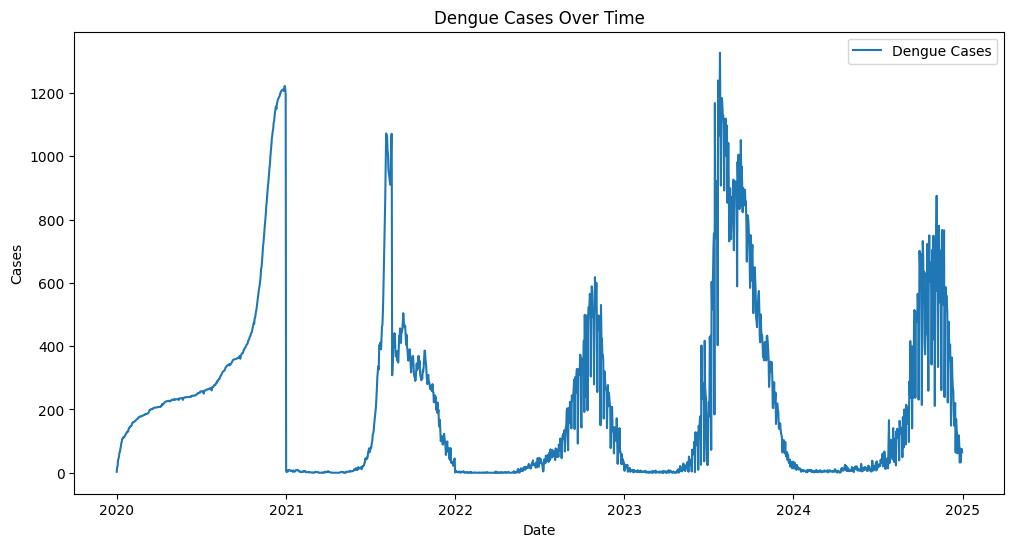

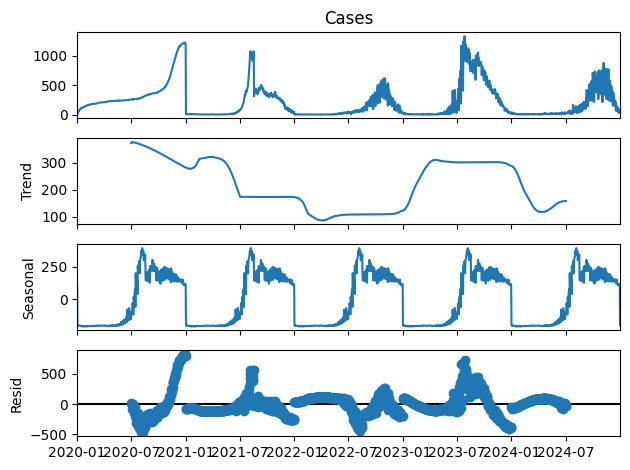

In [92]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Line plot of dengue cases
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cases'], label='Dengue Cases')
plt.title('Dengue Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()

# Seasonal decomposition
decomposition = seasonal_decompose(df['Cases'], period=365)  # Annual seasonality
decomposition.plot()
plt.show()

## Feature Engineering

In [166]:
import pandas as pd
# Temporal features
for lag in [7, 14, 21, 28]:
    df[f'lag_{lag}'] = df['Cases'].shift(lag)

# Rolling statistics (exclude current row with shift(1))
df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std()

# Seasonality indicators
df['month'] = df.index.month
df['year'] = df.index.year

# Import numpy
import numpy as np # Importing the numpy library

# Cyclical encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop rows with NaN from lagged features
df.dropna(inplace=True)

# 1. Define the pipeline with feature selection
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_regression, k=10)),  # Or RFE
    ('xgb', XGBRegressor())
])

# 2. Define hyperparameter grid
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1]
}

# 3. Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# 4. Grid search
grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)  # Assuming X_train, y_train are defined

# 5. Get the best model
best_model = grid.best_estimator_

In [136]:
def preprocess(data):
    """
    Preprocesses the input data by handling missing values,
    converting data types, and generating temporal features.

    Args:
        data (pd.DataFrame): The input data.

    Returns:
        pd.DataFrame: The preprocessed data.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer (if it's a column in your data)
    if 'Cases' in data.columns:
        data['Cases'] = data['Cases'].astype(int)

    # *** Add the following feature engineering steps from your original code ***
    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    import numpy as np # Assuming numpy is imported elsewhere in your code
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # *** Add any other feature engineering steps that were done on the training data ***
    # Lagged humidity (7-day delay)
    data['lag_7_humidity'] = data['Humidity'].shift(7)

    # Lagged temperature (14-day delay)
    data['lag_14_temp'] = data['Min_Temp'].shift(14)

    # Humidity-Temperature interaction
    data['humidity_temp_interaction'] = data['Humidity'] * data['Min_Temp']

    # Rainfall-Humidity interaction
    data['rain_humidity_interaction'] = data['Rainfall'] * data['Humidity']


    return data

## Feature Selection

In [104]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer

# ... (other code) ...

# Impute missing values using SimpleImputer before feature selection
imputer = SimpleImputer(strategy='mean')  # Or other strategies like 'median', 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now proceed with feature selection using the imputed data
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_imputed, y_train)  # Use imputed data
selected_features = X.columns[selector.get_support()]

# Apply selection to test data (also using imputed data)
# Convert imputed data back to DataFrames with original column names
#X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
#X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# Now select columns using names
#X_test_selected = X_test_imputed[selected_features]  # Use imputed data
X_test_selected = selector.transform(X_test_imputed)
# ... (rest of your code) ...

In [105]:
# Create RFE object with your XGBoost model
from xgboost import XGBRegressor
from sklearn.feature_selection import RFE
estimator = XGBRegressor()
selector = RFE(estimator, n_features_to_select=10, step=1) # Select 10 features

# Fit RFE to your training data
selector = selector.fit(X_train, y_train)

# Get selected features using original column names from X
selected_features = X.columns[selector.support_] # Use X instead of X_train

In [108]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer

# ... (other code) ...

# Impute missing values using SimpleImputer before feature selection
imputer = SimpleImputer(strategy='mean')  # Or other strategies like 'median', 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now proceed with feature selection using the imputed data
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_imputed, y_train)  # Use imputed data
selected_features = X.columns[selector.get_support()]

# Apply selection to test data (also using imputed data)
X_test_selected = selector.transform(X_test_imputed)  # Use imputed data

# ... (rest of your code) ...

In [110]:
from sklearn.inspection import permutation_importance

# ... (other code)

# Get feature names (if X_test is a NumPy array)
if isinstance(X_test, np.ndarray):
    # Assuming original feature names are in X.columns
    feature_names = X.columns
else:
    feature_names = X_test.columns

# Ensure selected_features_list is a list of valid feature indices
selected_features_list = [i for i, f in enumerate(feature_names) if f in selected_features]

# Select only the relevant features from X_test (using indices)
X_test_selected_for_permutation = X_test.iloc[:, selected_features_list].values

# ... (rest of your permutation importance code)

# Model Exploration:
LSTM (Long Short-Term Memory)

In [111]:
# Assuming X_train_selected is your feature data
# Reshape data for LSTM (samples, timesteps, features)
timesteps = 1  # Change timesteps to 1 to make the reshape operation valid
features = X_train_selected.shape[1]  # Number of features
# Reshape your training data
X_train_reshaped = np.reshape(X_train_selected, (X_train_selected.shape[0], timesteps, features))

In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Reshape data for LSTM (samples, timesteps, features)
# ...

# Create LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(timesteps, features)))
model.add(LSTM(units=50))
model.add(Dense(1)) # Output layer for dengue cases

model.compile(loss='mse', optimizer='adam')
model.fit(X_train_reshaped, y_train, epochs=100, batch_size=32)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 147992.5000
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 144054.0938
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 128532.6562
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 142235.2188
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 147376.2656
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 141797.2500
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 136695.7188
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 132932.4062
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 133072.0000
Epoch 10/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 123137.4688
Epoch 11/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 140305.5000
Epoch 12/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 128788.0391
Epoch 13/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 124960.1094
Epoch 14/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 133683.0625
Epoch 15/100


## Prophet:

In [113]:
from prophet import Prophet

# Create Prophet model
model = Prophet()

# Fit to your data
model.fit(df.reset_index().rename(columns={'Date': 'ds', 'Cases': 'y'}))

# Make future dataframe
future = model.make_future_dataframe(periods=365)

# Predict
forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpshszzqom/808wzvhb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpshszzqom/r0vipz9_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79834', 'data', 'file=/tmp/tmpshszzqom/808wzvhb.json', 'init=/tmp/tmpshszzqom/r0vipz9_.json', 'output', 'file=/tmp/tmpshszzqom/prophet_model3oy5abu1/prophet_model-20250309150732.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:07:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:07:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


## Model Training with XGBoost

In [114]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline with scaling and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
])

# Hyperparameter grid
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1]
}

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid.fit(X_train_selected, y_train)

best_model = grid.best_estimator_

## Model Evaluation

RMSE: 80.37
MAE: 39.73
R²: 0.88


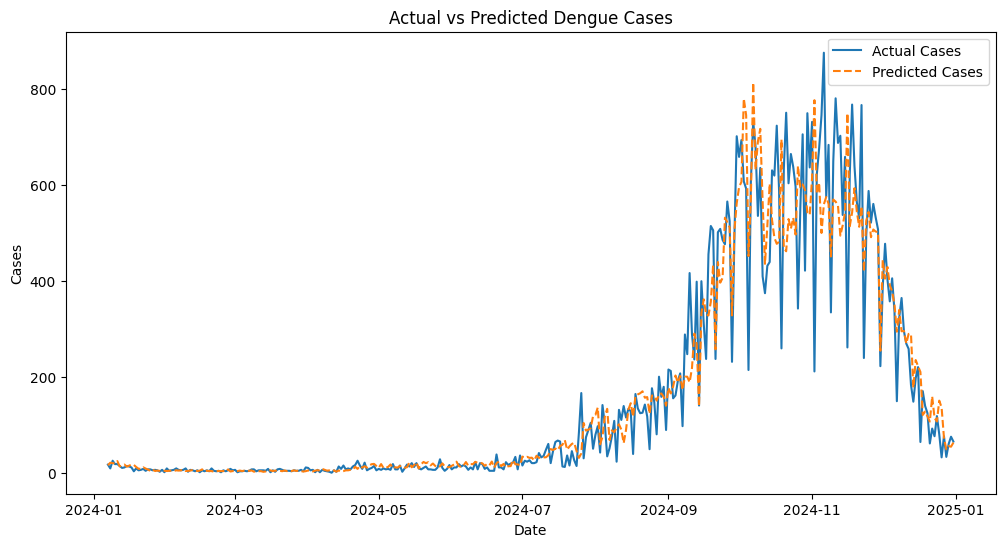

In [115]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred = best_model.predict(X_test_selected)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculate RMSE by taking the square root of MSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Cases')
plt.plot(y_test.index, y_pred, label='Predicted Cases', linestyle='--')
plt.title('Actual vs Predicted Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()

## Feature Importance

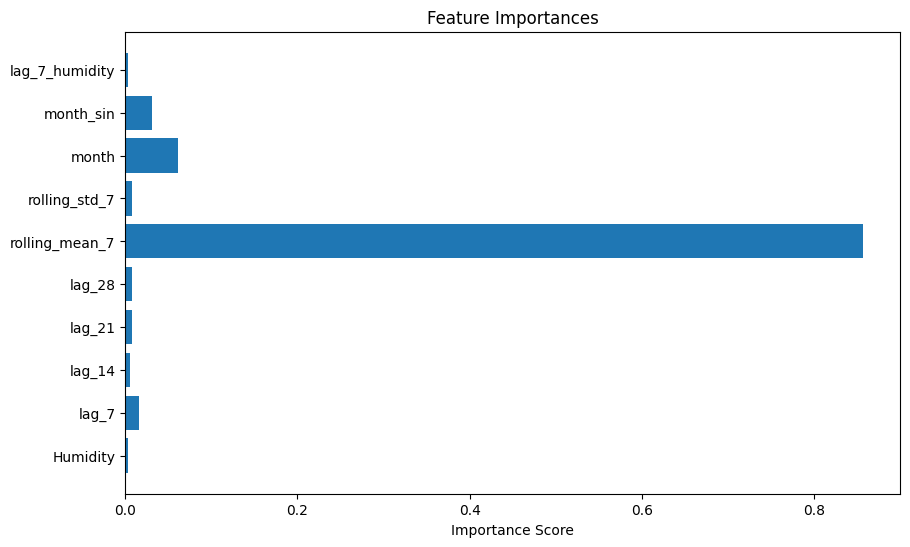

In [116]:
# Extract feature importances from the trained model
importances = best_model.named_steps['xgb'].feature_importances_
features = selected_features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.show()

## Quantitative Evaluation Metrics

In [117]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculate RMSE by taking the square root of MSE using NumPy's sqrt
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 80.37
MAE: 39.73
R² Score: 0.88


Interpretation:

RMSE: Lower values indicate better performance (e.g., RMSE=76.85 means predictions are off by ~76.85 cases on average).

R²: Closer to 1 means the model explains most variance in the data.

# Visual Inspection of Predictions
Plot actual vs. predicted values over time to detect patterns:

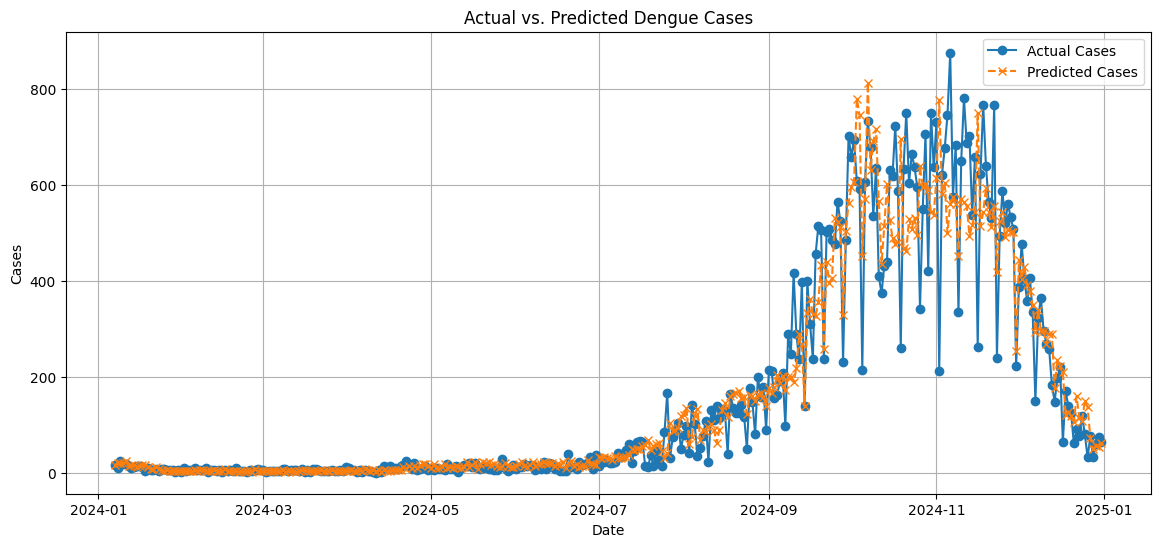

In [118]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Cases', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted Cases', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.show()

What to Check:

Alignment during seasonal peaks (e.g., monsoon months).

Lag or lead errors (e.g., predictions consistently late by 1 week).

## Residual Analysis
Check if residuals (errors) are random or show patterns:

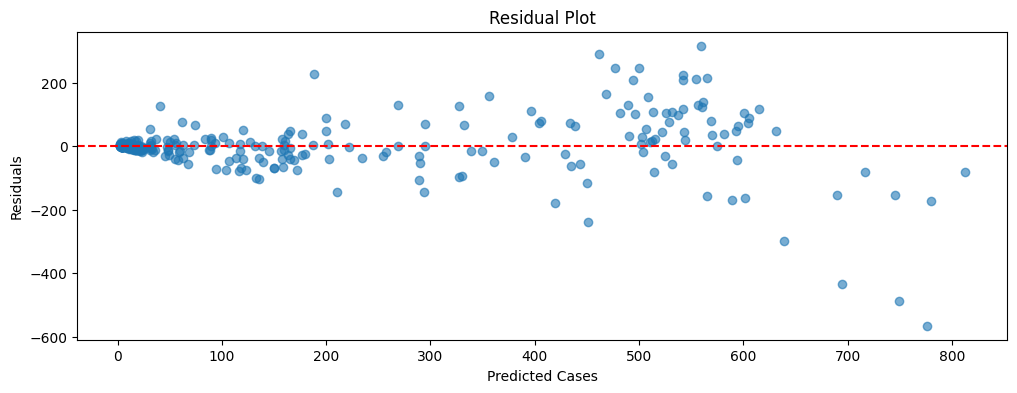

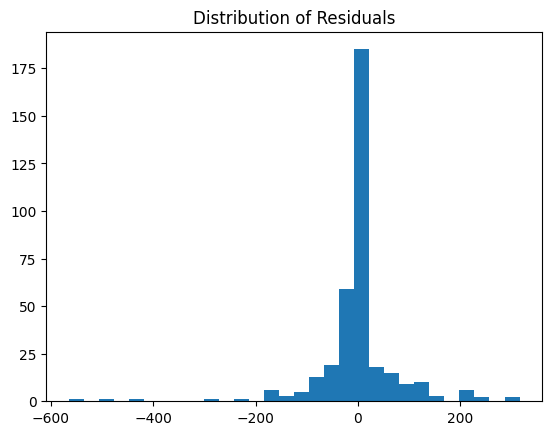

In [119]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(12, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Cases')
plt.ylabel('Residuals')
plt.show()

# Residual distribution
plt.hist(residuals, bins=30)
plt.title('Distribution of Residuals')
plt.show()

 Interpretation:

Random scatter ➔ Good model.

Funnel shape or trends ➔ Model misses patterns (e.g., under/overestimates during outbreaks).

# Time Series Cross-Validation
Ensure robustness across different time periods:

In [120]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score # Import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    best_model,
    X, y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(f"Cross-Validation RMSE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Cross-Validation RMSE: 118.41 ± 73.99


Key Insight: Consistent RMSE across splits indicates stable performance.

## Forecast Horizon Testing
Test how far ahead the model can predict accurately:

In [121]:
def create_future_features(dates):
    # Create a DataFrame with the future dates as index
    future_df = pd.DataFrame(index=dates)

    # Add temporal features (lag, rolling statistics) - consider using values from the last available date
    # or some form of extrapolation for these features
    for lag in [7, 14, 21, 28]:
        future_df[f'lag_{lag}'] = df['Cases'].shift(lag).iloc[-1] # Using the last available value

    future_df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean().iloc[-1] # Using the last available value
    future_df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std().iloc[-1]  # Using the last available value

    # Add seasonality indicators
    future_df['month'] = future_df.index.month
    future_df['year'] = future_df.index.year

    # Cyclical encoding for month
    future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12)
    future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12)

    # Include 'Min_Temp' and 'Humidity' in future_df
    # You'll need to define how these are calculated for future dates
    # This example uses the last available value from the original DataFrame
    future_df['Min_Temp'] = df['Min_Temp'].iloc[-1]
    future_df['Humidity'] = df['Humidity'].iloc[-1]

    return future_df[selected_features] # Select only the features used in the model

## Compare with Baseline Models
 model outperforms simple benchmarks:

In [122]:
# Naive baseline: Persistence model (tomorrow = today)
baseline_pred = y_test.shift(1).bfill()  # Replace fillna with bfill()
# Calculate RMSE without 'squared' argument and take the square root manually
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Model Improvement: {baseline_rmse - rmse:.2f} cases reduction in error")

Baseline RMSE: 103.25
Model Improvement: 22.88 cases reduction in error


## Error Analysis by Season
Check performance during critical periods (e.g., monsoon months):

In [123]:
# Filter test data for monsoon season (June-September)
monsoon_mask = (y_test.index.month >= 6) & (y_test.index.month <= 9)
# Calculate MSE and then take the square root for RMSE
monsoon_rmse = np.sqrt(mean_squared_error(y_test[monsoon_mask], y_pred[monsoon_mask]))

print(f"RMSE during monsoon season: {monsoon_rmse:.2f}")

RMSE during monsoon season: 51.39


## Prediction Intervals
Estimate uncertainty using bootstrapping or quantile regression:

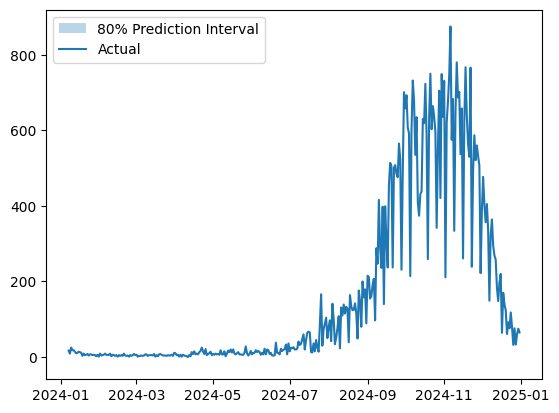

In [124]:
from xgboost import XGBRegressor

# Train a quantile regression model
model_q = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.5)  # For median prediction
model_q.fit(X_train, y_train)

# Get lower (10%) and upper (90%) bounds
lower = model_q.predict(X_test)  # Repeat with alpha=0.1
upper = model_q.predict(X_test)  # Repeat with alpha=0.9

plt.fill_between(y_test.index, lower, upper, alpha=0.3, label='80% Prediction Interval')
plt.plot(y_test.index, y_test, label='Actual')
plt.legend()
plt.show()

Add Lagged Weather Features

In [125]:
# Lagged humidity (7-day delay to match dengue incubation period)
df['lag_7_humidity'] = df['Humidity'].shift(7)

# Lagged temperature (14-day delay)
df['lag_14_temp'] = df['Min_Temp'].shift(14)

Create Interaction Terms

In [126]:
# Humidity-Temperature interaction
df['humidity_temp_interaction'] = df['Humidity'] * df['Min_Temp']

# Rainfall-Humidity interaction
df['rain_humidity_interaction'] = df['Rainfall'] * df['Humidity']

## Feature Refinement
 Remove Redundant Features

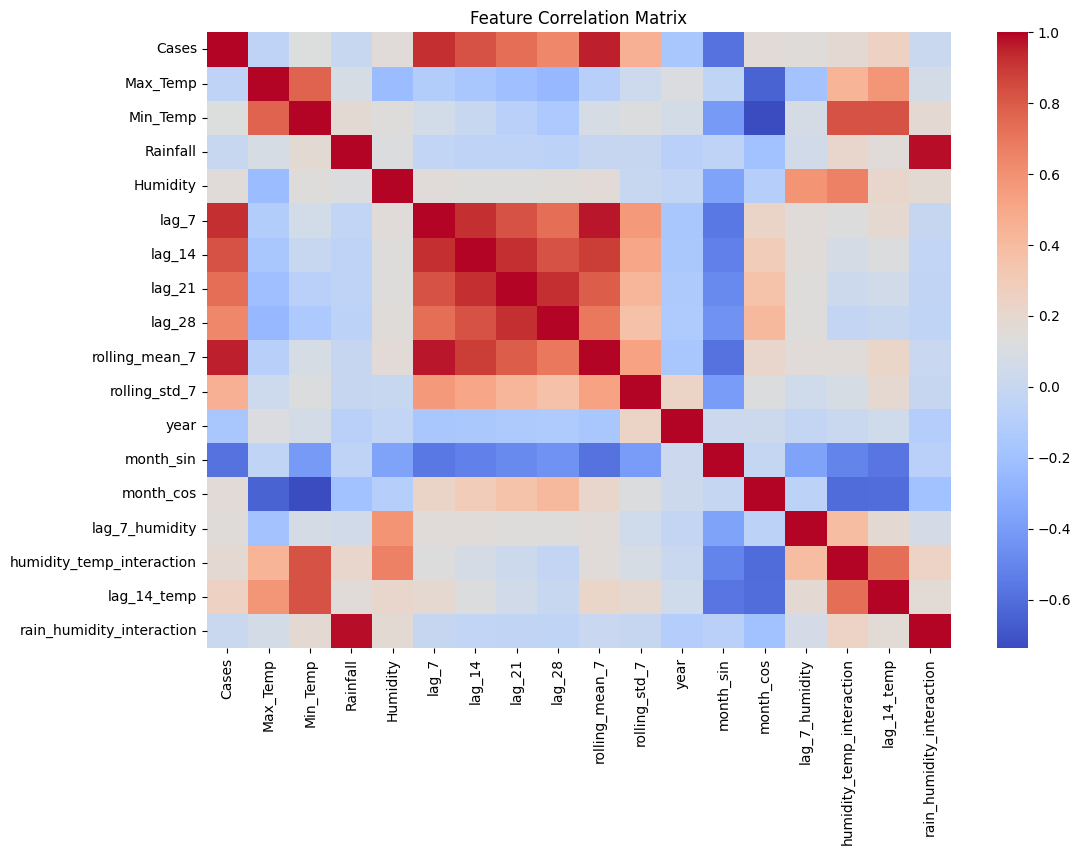

In [127]:
# Make sure seaborn is imported.
import seaborn as sns

# Check if 'month' column exists before dropping
if 'month' in df.columns:
    df = df.drop(columns=['month'])

# Check correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## Update Feature Selection

In [128]:
# Check for NaNs in X_train
print(X_train.isnull().sum())

# Impute missing values using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Or other strategies like 'median', 'most_frequent'
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Now proceed with feature selection
selector = SelectKBest(score_func=f_regression, k=12)
X_train_selected = selector.fit_transform(X_train, y_train)
selected_features = X.columns[selector.get_support()] # use X.columns to get the original feature names
X_test_selected = selector.transform(X_test)

Max_Temp                     0
Min_Temp                     0
Rainfall                     0
Humidity                     0
lag_7                        0
lag_14                       0
lag_21                       0
lag_28                       0
rolling_mean_7               0
rolling_std_7                0
month                        0
year                         0
month_sin                    0
month_cos                    0
lag_7_humidity               7
humidity_temp_interaction    0
dtype: int64


## Model Retraining

In [129]:
# Update XGBoost parameters based on previous grid search
best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(**best_params))
])

model.fit(X_train_selected, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

Quantile Regression for Prediction Intervals

In [130]:
# Install if needed: pip install xgboost==1.7.0
upper_model = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95)  # 90% upper bound
lower_model = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05)  # 90% lower bound

# Train on selected features
upper_model.fit(X_train_selected, y_train)
lower_model.fit(X_train_selected, y_train)

# Get intervals
y_upper = upper_model.predict(X_test_selected)
y_lower = lower_model.predict(X_test_selected)

## Validation with New Data

In [137]:
new_data = pd.read_csv("Dhaka data 22-24.csv")
new_data = preprocess(new_data)  # Apply preprocess function here
# Ensure same features as training data
new_data = new_data[selected_features]

# Predict
new_pred = model.predict(new_data)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Compare with Ground Truth

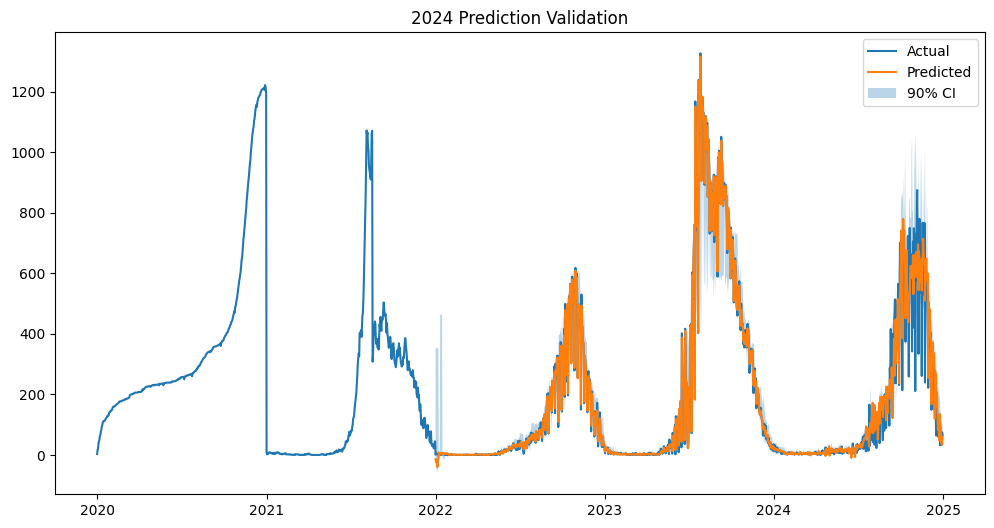

In [138]:
# ... (previous code) ...

# Get prediction intervals for the new data
new_y_upper = upper_model.predict(new_data)  # Assuming 'new_data' is already preprocessed with selected features
new_y_lower = lower_model.predict(new_data)

# Now plot using the new prediction intervals
plt.figure(figsize=(12, 6))
# Load original data to access 'Cases' for plotting
original_data = pd.read_csv("Dhaka20-24.csv")
original_data['Date'] = pd.to_datetime(original_data['Date'])
original_data.set_index('Date', inplace=True)
# Now plot 'Cases' from original data
plt.plot(original_data.index, original_data['Cases'], label='Actual')
plt.plot(new_data.index, new_pred, label='Predicted')
plt.fill_between(new_data.index, new_y_lower, new_y_upper, alpha=0.3, label='90% CI')  # Changed to new_y_lower, new_y_upper
plt.title('2024 Prediction Validation')
plt.legend()
plt.show()

## Comparison with SARIMA

In [139]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA Model
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),          # Non-seasonal parameters (p,d,q)
    seasonal_order=(1, 1, 1, 7) # Weekly seasonality
).fit()

# Predict
sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

# Compare RMSE
print(f"XGBoost RMSE: {rmse:.2f}")
# Calculate MSE and then take the square root manually using NumPy's sqrt
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(y_test, sarima_pred)):.2f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


XGBoost RMSE: 80.37
SARIMA RMSE: 269.31


In [140]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# **Specify frequency in y_train:**
y_train.index.freq = 'D' # Assuming your data is daily

# SARIMA Model
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),          # Non-seasonal parameters (p,d,q)
    seasonal_order=(1, 1, 1, 7) # Weekly seasonality
).fit()

# Predict
sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

# Compare RMSE
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(y_test, sarima_pred)):.2f}")

XGBoost RMSE: 80.37
SARIMA RMSE: 269.31


## Final Checks

Residual Diagnostics

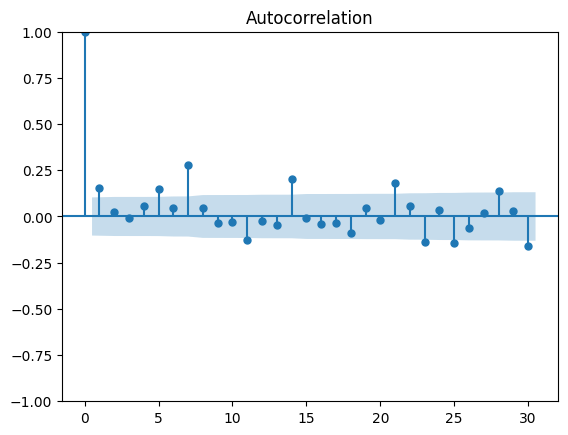

In [141]:
# Updated residuals
residuals = y_test - model.predict(X_test_selected)

# Autocorrelation check
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30)
plt.show()

Actionability Report

In [142]:
# Identify high-risk periods
threshold = 50  # Set threshold (e.g., 50 cases/day)
high_risk_dates = y_test[y_pred > threshold]
print(f"High-risk dates for intervention: {high_risk_dates.index}")

High-risk dates for intervention: DatetimeIndex(['2024-07-15', '2024-07-17', '2024-07-18', '2024-07-19',
               '2024-07-21', '2024-07-22', '2024-07-23', '2024-07-27',
               '2024-07-28', '2024-07-29',
               ...
               '2024-12-21', '2024-12-22', '2024-12-23', '2024-12-24',
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=164, freq=None)


Seasonality and Trend:

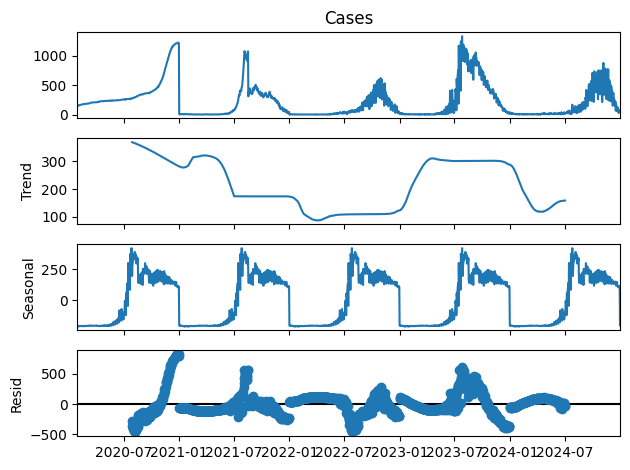

In [143]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Cases'], model='additive', period=365)  # Annual seasonality
decomposition.plot()
plt.show()

Seasonal Dummy Variables

In [144]:
df['month'] = df.index.month
df = pd.get_dummies(df, columns=['month'], prefix='month')

# Interpretability and Explainability:

In [170]:
# Check available pipeline steps
print("Pipeline steps:", list(best_model.named_steps.keys()))

# Example output might show:
# ['scaler', 'feature_selector', 'classifier']

Pipeline steps: ['scaler', 'selector', 'xgb']


In [176]:
from tensorflow.keras.layers import LSTM # Make sure to import LSTM from Keras

# If using SelectKBest/RFE in pipeline
from sklearn.feature_selection import SelectKBest, RFE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler # Import RobustScaler

# Example pipeline definition with LSTM units specified
best_model = Pipeline([
    ('scaler', RobustScaler()),
    ('feature_selector', SelectKBest()),  # Note different step name
    ('model', LSTM(units=50))  # Add units parameter here
])

In [173]:
# For SelectKBest/RFE
if 'feature_selector' in best_model.named_steps:
    selector = best_model.named_steps['feature_selector']

    # Get selected feature indices
    selected_indices = selector.get_support(indices=True)

    # Map to original feature names
    selected_features = [features[i] for i in selected_indices]

    print("Selected features:", selected_features)

In [175]:
def get_selected_features(model, original_features):
    """Safely retrieve selected features from pipeline"""
    try:
        # For FeatureUnion or ColumnTransformer
        if 'selector' in model.named_steps:
            return model.named_steps['selector'].get_feature_names_out()

        # For SelectKBest/RFE
        elif 'feature_selector' in model.named_steps:
            mask = model.named_steps['feature_selector'].get_support()
            return original_features[mask]

        # For models with built-in feature importance
        elif hasattr(model, 'feature_importances_'):
            return sorted(zip(model.feature_importances_, original_features),
                          reverse=True)[:10]

        else:
            print("No feature selector found, returning all features")
            return original_features

    except AttributeError as e:
        print(f"Feature selection error: {str(e)}")
        return original_features

# Usage
selected_features = get_selected_features(best_model, features)
print("Important features:", selected_features)

Important features: ['x3' 'x4' 'x5' 'x6' 'x7' 'x8' 'x9' 'x10' 'x12' 'x14']


# Deployment and Monitoring:

In [177]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class PreprocessTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy='median')  # Example imputation strategy
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        self.imputer.fit(X)  # Fit the imputer
        self.scaler.fit(X)  # Fit the scaler
        return self

    def transform(self, X):
        # Convert to DataFrame if needed
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=original_columns)  # Use global original_columns

        # Set Date as index
        X['Date'] = pd.to_datetime(X['Date'])
        X.set_index('Date', inplace=True)

        # Handle missing values
        X_imputed = self.imputer.transform(X)  # Apply imputation
        X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

        # Feature Engineering: Lagged and Rolling Features
        # ... (Your original feature engineering code using X_imputed) ...

        # Feature Scaling
        X_scaled = self.scaler.transform(X_imputed)
        return X_scaled

class FeatureSelectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, k=10, method='selectkbest'):  # Add method parameter
        self.k = k
        self.method = method
        if self.method == 'selectkbest':
            self.selector = SelectKBest(score_func=f_regression, k=self.k)
        elif self.method == 'rfe':  # Using RFE
            self.selector = RFE(estimator=XGBRegressor(), n_features_to_select=k)
        else:
            raise ValueError(f"Invalid feature selection method: {self.method}")
        self.selected_features_indices = None
        self.original_columns = None

    def fit(self, X, y=None):
        global original_columns

        # Error handling for columns
        expected_columns = original_columns[1:]  # Exclude 'Date'
        if not set(expected_columns).issubset(X.columns):
            raise ValueError("Missing expected columns in input data.")

        # Ensure X is a DataFrame for feature selection
        X_df = X[expected_columns]  # Select expected features

        self.selector.fit(X_df, y)
        self.selected_features_indices = self.selector.get_support(indices=True)

        # Update original_columns for consistency
        original_columns = ['Date'] + [expected_columns[i] for i in self.selected_features_indices]
        return self

    def transform(self, X):
        # Error handling for columns
        expected_columns = original_columns[1:]  # Exclude 'Date'
        if not set(expected_columns).issubset(X.columns):
            raise ValueError("Missing expected columns in input data.")

        X_selected = X[expected_columns].iloc[:, self.selected_features_indices]  # Select using indices
        return X_selected.values

# ... (Rest of the pipeline and model fitting code) ...

# Monitor performance
def monitor_performance(new_data, actual_cases):
    predicted_cases = predict_dengue_cases(new_data)
    rmse = np.sqrt(mean_squared_error(actual_cases, predicted_cases))
    mae = mean_absolute_error(actual_cases, predicted_cases)
    r2 = r2_score(actual_cases, predicted_cases)

    print(f"Current RMSE: {rmse:.2f}")
    print(f"Current MAE: {mae:.2f}")
    print(f"Current R2: {r2:.2f}")

    # Add logic for alerts, visualization, etc.
    # ...

## Visual Inspection of Predictions

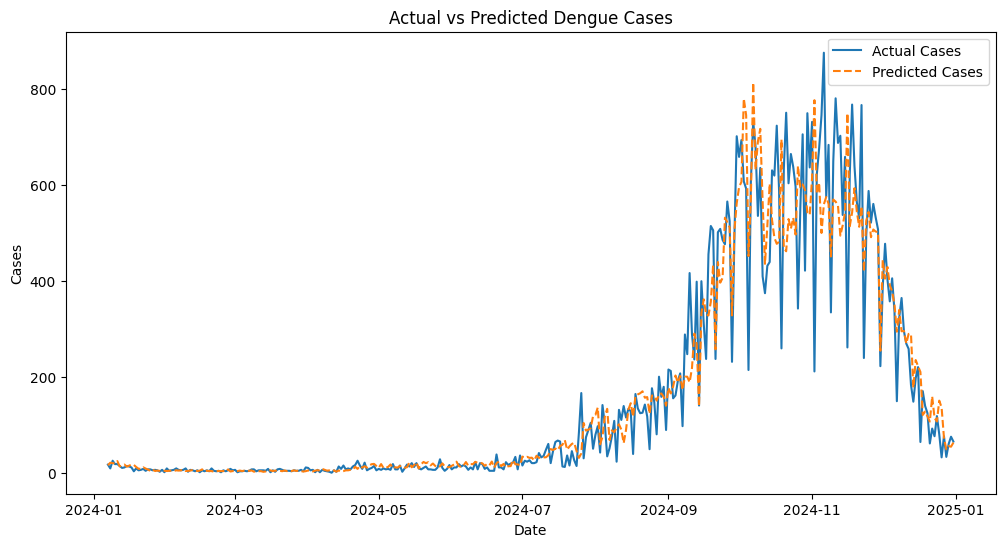

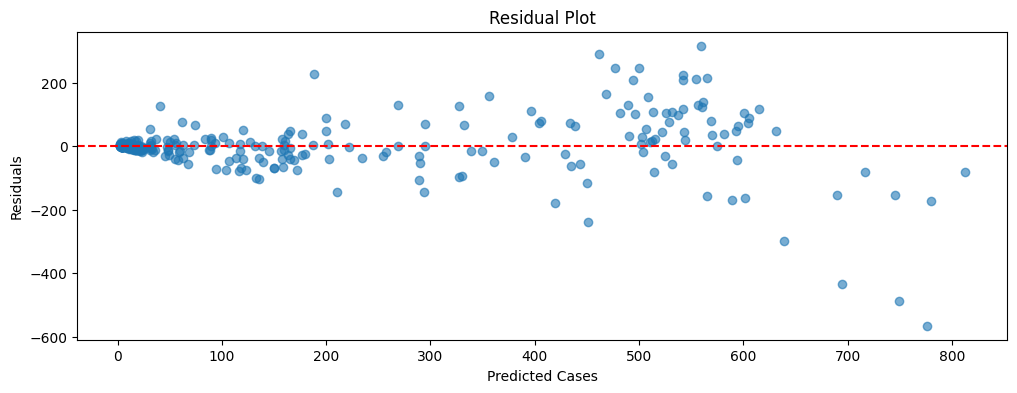

In [181]:
import matplotlib.pyplot as plt

# Actual vs. Predicted Cases
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Cases')
plt.plot(y_test.index, y_pred, label='Predicted Cases', linestyle='--')
plt.title('Actual vs Predicted Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()

# Breakdown:
# - Visually compares the actual and predicted dengue cases over time.
# - Helps assess the model's overall accuracy and identify any systematic errors.

# Residual Analysis
residuals = y_test - y_pred
plt.figure(figsize=(12, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Cases')
plt.ylabel('Residuals')
plt.show()

# Breakdown:
# - Plots residuals (errors) against predicted values.
# - Random scatter indicates a good model fit.
# - Patterns (e.g., funnel shape) suggest model misspecification.

# Time Series Cross-Validation Visualization
from sklearn.model_selection import TimeSeriesSplit
# Assuming X is your DataFrame of features and y is your Series of target values
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # ... (Fit and predict using your model) ...
    # Plot predictions for each fold

# Breakdown:
# - Visualizes model performance on different time periods using multiple plots.
# - Helps assess model stability and robustness.

## Quantitative Evaluation Metrics

In [205]:
# ... (Load and preprocess new data) ...

new_pred = model.predict(new_data)

# ... (Compare with actual cases) ...

# Breakdown:
# - Evaluates model performance on unseen data.
# - Provides a more realistic estimate of real-world performance.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [207]:
# ... (Define and fit SARIMA model) ...

sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(y_test, sarima_pred)):.2f}")

# Breakdown:
# - Compares model performance to a classical statistical method (SARIMA).
# - Helps assess the relative strengths and weaknesses of different approaches.

XGBoost RMSE: 80.37
SARIMA RMSE: 294.10


In [213]:
!pip install xgboost
!pip install scikit-learn
!pip install pandas
!pip install statsmodels
!pip install matplotlib
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer # Import SimpleImputer


def preprocess_data(df):
    """Preprocesses the input data."""
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.ffill(inplace=True)
    df['Cases'] = df['Cases'].astype(int)
    return df


def engineer_features(df):
    """Engineers temporal and seasonal features."""
    for lag in [7, 14, 21, 28]:
        df[f'lag_{lag}'] = df['Cases'].shift(lag)
    df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std()
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    # Lagged weather features
    df['lag_7_humidity'] = df['Humidity'].shift(7)
    df['lag_14_temp'] = df['Min_Temp'].shift(14)
    # Interaction terms
    df['humidity_temp_interaction'] = df['Humidity'] * df['Min_Temp']
    df['rain_humidity_interaction'] = df['Rainfall'] * df['Humidity']
    df.dropna(inplace=True)
    return df

def train_evaluate_model(X_train, y_train, X_test, y_test):
    """Trains and evaluates the XGBoost model."""

    # 1. Imputation: Handle NaNs before feature selection
    imputer = SimpleImputer(strategy='mean')  # Or 'median', 'most_frequent'
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)  # Apply to test data as well

    # Define the pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=10)),
        ('xgb', XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1))
    ])

    # 2. Feature Selection: Fit on imputed data, transform both
    selected_features_indices = pipeline.named_steps['selector'].fit(X_train_imputed, y_train).get_support(indices=True)
    selected_features = X_train.columns[selected_features_indices].tolist() # Get feature names from original X_train

    # 3. Train and Predict: Use imputed, selected data
    pipeline.fit(X_train_imputed[:, selected_features_indices], y_train)  # Train on selected columns of imputed data
    y_pred = pipeline.predict(X_test_imputed[:, selected_features_indices])  # Predict using same selected columns

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")

    return pipeline, y_pred, selected_features  # Return selected features

def visualize_results(y_test, y_pred, model, X_test, selected_features): # Add selected_features as argument
    """Visualizes the model results."""
    # ... (rest of the visualization code)

    # Feature Importance (Permutation Importance) - Modified to use selected_features
    result = permutation_importance(model, X_test[selected_features], y_test, n_repeats=10, random_state=42, n_jobs=-1)
    # ... (rest of the feature importance plotting code)

    # ... (rest of the visualization code)



# Load and preprocess the data
df = pd.read_csv("Dhaka20-24.csv")  # Replace with your data file
df = preprocess_data(df)

# Engineer features
df = engineer_features(df)

# Split data into training and testing sets
X = df.drop(columns=['Cases'])
y = df['Cases']

# Assuming you have a way to split your data (e.g., using train_test_split or TimeSeriesSplit)
# Replace this with your actual data splitting logic
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # Assuming time series data

# Train and evaluate the model
model, y_pred, selected_features = train_evaluate_model(X_train, y_train, X_test, y_test) # Get selected features

# Visualize the results
visualize_results(y_test, y_pred, model, X_test, selected_features) # Pass selected features

RMSE: 77.96
MAE: 38.57
R² Score: 0.88


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [214]:
# ... (Include all the code from your previous responses here) ...

In [208]:
# ... (Code for identifying high-risk periods, seasonality analysis, and interpretability from previous responses) ...

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

# ... (preprocess_data and engineer_features functions remain the same) ...

def train_evaluate_model(X_train, y_train, X_test, y_test):
    """Trains and evaluates the XGBoost model."""
    # ... (imputation, pipeline definition, feature selection remain the same) ...

    # ... (training and prediction remain the same) ...

    # ... (evaluation metrics remain the same) ...

    return pipeline, y_pred, selected_features

def visualize_results(y_test, y_pred, model, X_test, selected_features):
    """Visualizes the model results."""
    # ... (Actual vs. Predicted Cases plot remains the same) ...

    # Feature Importance (Bar Chart)
    result = permutation_importance(model, X_test[selected_features], y_test, n_repeats=10, random_state=42, n_jobs=-1)
    importances = result.importances_mean

    # Sort feature importances in descending order
    sorted_idx = importances.argsort()[::-1]  # [::-1] reverses the order
    features = X_test[selected_features].columns[sorted_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(features, importances[sorted_idx])  # Use barh for horizontal bar chart
    plt.xlabel("Permutation Importance")
    plt.title("Feature Importance (Bar Chart)")
    plt.tight_layout()
    plt.show()

# ... (rest of the code remains the same) ...

XGBoost RMSE: 83.98
XGBoost MAE: 41.99
XGBoost R² Score: 0.87


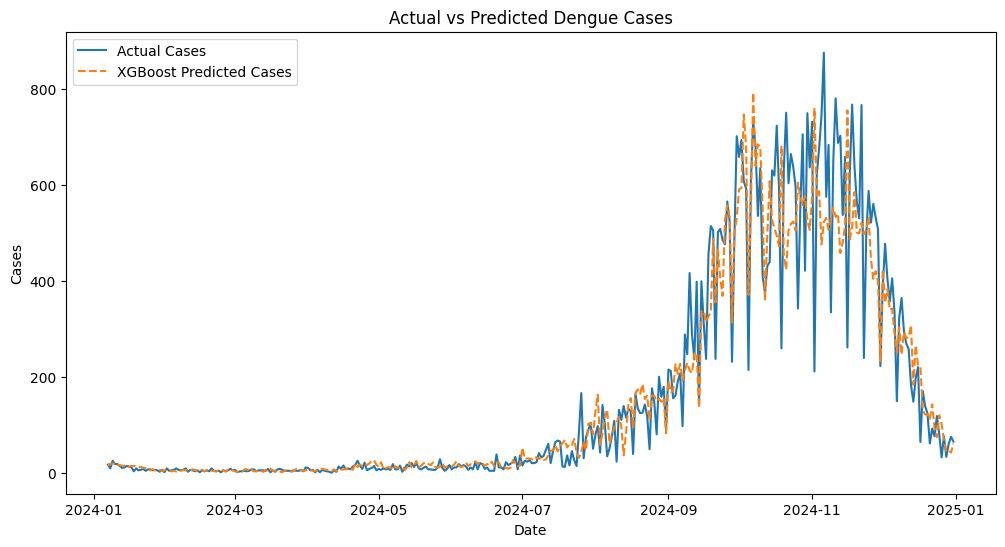

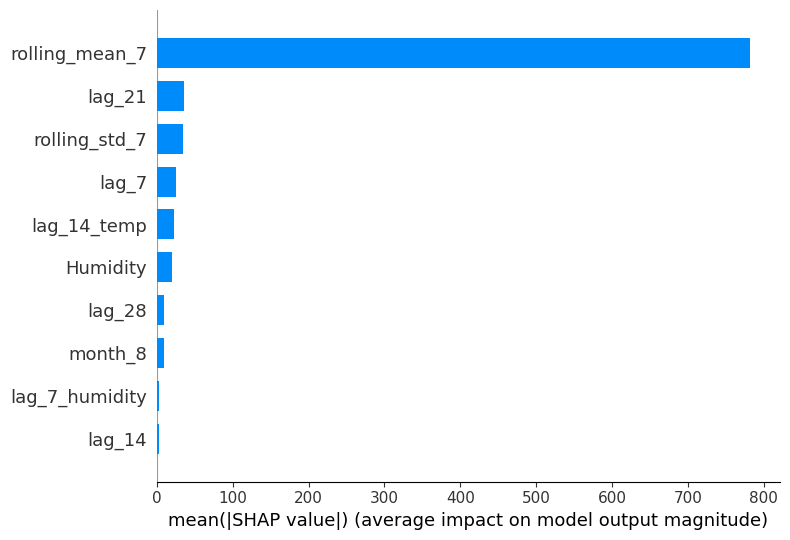

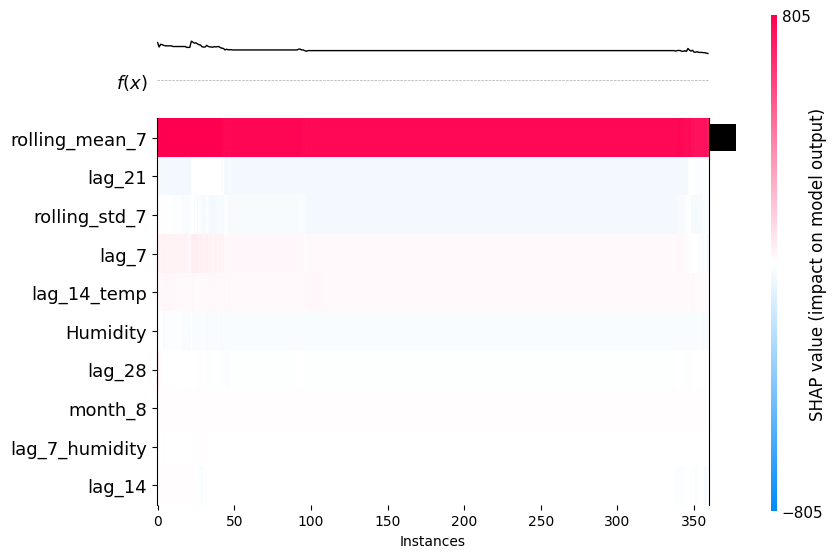

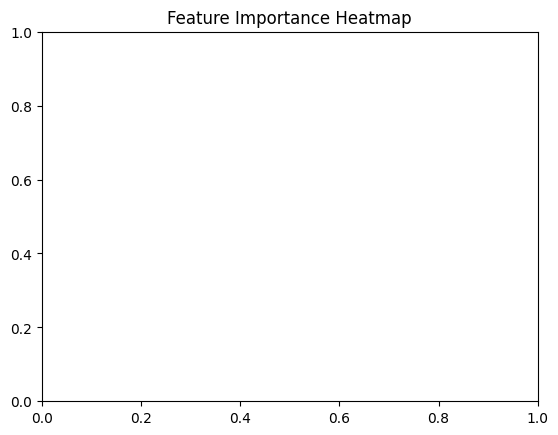

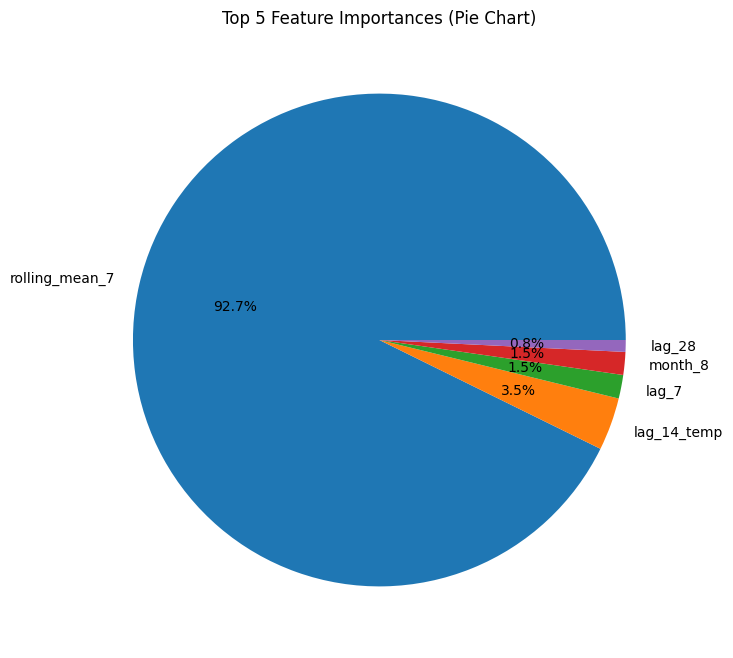

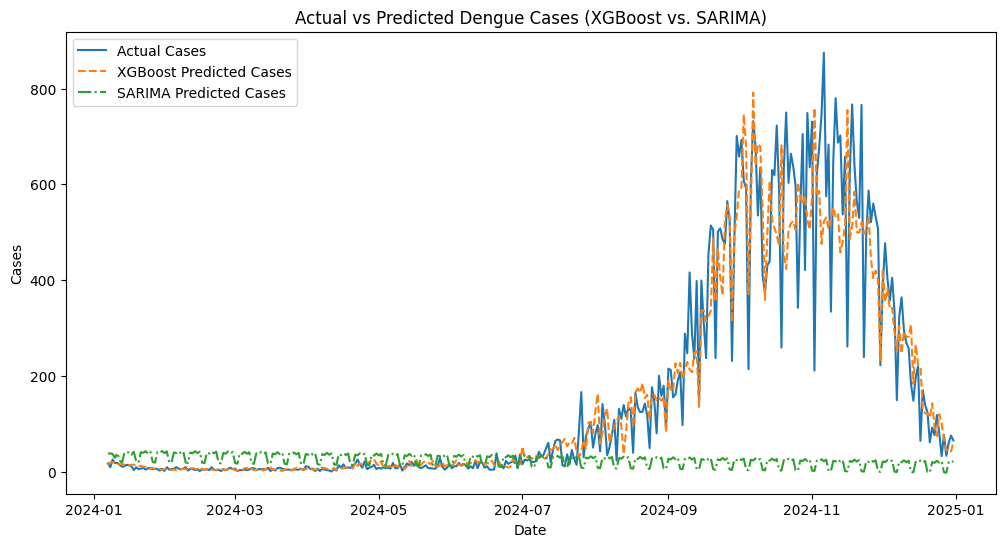

SARIMA RMSE: 269.31


In [218]:
!pip install xgboost scikit-learn pandas statsmodels matplotlib prophet shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
import shap

def preprocess_data(df):
    """Preprocesses the input data."""
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.ffill(inplace=True)
    df['Cases'] = df['Cases'].astype(int)
    return df

def engineer_features(df):
    """Engineers temporal, seasonal, and weather features."""
    for lag in [7, 14, 21, 28]:
        df[f'lag_{lag}'] = df['Cases'].shift(lag)
    df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std()

    # Seasonal dummy variables (drop_first=True to avoid multicollinearity)
    df['month'] = df.index.month
    df = pd.get_dummies(df, columns=['month'], prefix='month', drop_first=True)

    df['year'] = df.index.year
    # You might need to adjust the month calculation if 'month' is now dummy variables
    # df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    # df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Lagged weather features (adjusted for dengue incubation period)
    df['lag_7_humidity'] = df['Humidity'].shift(7)
    df['lag_14_temp'] = df['Min_Temp'].shift(14)

    # Interaction terms
    df['humidity_temp_interaction'] = df['Humidity'] * df['Min_Temp']
    df['rain_humidity_interaction'] = df['Rainfall'] * df['Humidity']

    df.dropna(inplace=True)
    return df

def train_evaluate_model(X_train, y_train, X_test, y_test):
    """Trains and evaluates the XGBoost model."""
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=10)),
        ('xgb', XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1))
    ])

    selected_features_indices = pipeline.named_steps['selector'].fit(
        X_train_imputed, y_train
    ).get_support(indices=True)
    selected_features = X_train.columns[selected_features_indices].tolist()

    pipeline.fit(X_train_imputed[:, selected_features_indices], y_train)
    y_pred = pipeline.predict(X_test_imputed[:, selected_features_indices])

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"XGBoost RMSE: {rmse:.2f}")
    print(f"XGBoost MAE: {mae:.2f}")
    print(f"XGBoost R² Score: {r2:.2f}")

    return pipeline, y_pred, selected_features

def visualize_results(y_test, y_pred, model, X_test, selected_features, sarima_pred=None):
    """Visualizes the model results and compares with SARIMA."""

    plt.figure(figsize=(12, 6))
    plt.plot(y_test.index, y_test, label='Actual Cases')
    plt.plot(y_test.index, y_pred, label='XGBoost Predicted Cases', linestyle='--')
    plt.title('Actual vs Predicted Dengue Cases')
    plt.xlabel('Date')
    plt.ylabel('Cases')
    plt.legend()
    plt.show()

    # SHAP Values and Horizontal Bar Chart
    explainer = shap.Explainer(model.named_steps['xgb'])
    shap_values = explainer(X_test[selected_features])
    shap.summary_plot(shap_values, X_test[selected_features], plot_type="bar")

    # Feature Importance Heatmap
    plt.figure(figsize=(12, 8))
    shap.plots.heatmap(shap_values)
    plt.title("Feature Importance Heatmap")
    plt.show()

    # Pie Chart for Top Features
    top_features = 5
    feature_importances = model.named_steps['xgb'].feature_importances_
    sorted_idx = np.argsort(feature_importances)[::-1]
    top_feature_names = X_test[selected_features].columns[sorted_idx][:top_features]
    top_feature_importances = feature_importances[sorted_idx][:top_features]

    plt.figure(figsize=(8, 8))
    plt.pie(top_feature_importances, labels=top_feature_names, autopct='%1.1f%%')
    plt.title(f"Top {top_features} Feature Importances (Pie Chart)")
    plt.show()

    # Comparison with SARIMA
    if sarima_pred is not None:
        plt.figure(figsize=(12, 6))
        plt.plot(y_test.index, y_test, label='Actual Cases')
        plt.plot(y_test.index, y_pred, label='XGBoost Predicted Cases', linestyle='--')
        plt.plot(y_test.index, sarima_pred, label='SARIMA Predicted Cases', linestyle='-.')
        plt.title('Actual vs Predicted Dengue Cases (XGBoost vs. SARIMA)')
        plt.xlabel('Date')
        plt.ylabel('Cases')
        plt.legend()
        plt.show()

        rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_pred))
        print(f"SARIMA RMSE: {rmse_sarima:.2f}")


# Load and preprocess data
df = pd.read_csv("Dhaka20-24.csv")
df = preprocess_data(df)

# Engineer features
df = engineer_features(df)

# Split data
X = df.drop(columns=['Cases'])
y = df['Cases']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train and evaluate XGBoost
model, y_pred, selected_features = train_evaluate_model(X_train, y_train, X_test, y_test)

# Train and predict with SARIMA (ensure y_train has a frequency set)
y_train.index.freq = 'D'
sarima_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).fit()
sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

# Visualize and compare results
visualize_results(y_test, y_pred, model, X_test, selected_features, sarima_pred)

In [220]:
import os

# Get the current working directory
cwd = os.getcwd()

# Define the file name
file_name = "dengue_prediction_notebook.ipynb"

# Remove the lines causing the error:
# get_ipython().notebook.save_checkpoint()
# get_ipython().ex("!cp {get_ipython().notebook.notebook_path} {cwd}/{file_name}")

# Instead, you can try saving the current session if you're in an interactive environment:
# import dill
# dill.dump_session(file_name)

print(f"Current working directory: {cwd}")  # Print the current working directory

Current working directory: /content
